## Extension to a second household

*This is an extension of the model from [this writeup](https://github.com/rcberg/macroeconomics/blob/main/reports/general-eqm-1x2x3-writeup/general-equilibrium-1x2x3-writeup.ipynb) to include a second household. Because the production side as well as most of the factor side are the same, this current writeup will focus on what's new. For details which are skipped here, interested readers are encouraged to check out the above link.*

## The economics

As mentioned, the extension studied here adds a second representative household, giving us a 2-household; 2-firm; 3-factor model. Here, one household is the "working" household, earning all income from supplying labor. The second household is [a pure landlord-capitalist](https://en.wikipedia.org/wiki/Rentier_capitalism) who rents land to the firms, and raises any necessary capital the economy needs in equilibrium.

The final demand side accordingly shifts to two utility functions, $$ U_A = Q_A \left( \eta_x x_A^\alpha + \eta_y y_A^\alpha + (1 - \eta_x - \eta_y)N_l^\alpha \right)^{1/\alpha} $$ $$ U_B = Q_B \left( \phi_x x_B^\alpha + (1 - \phi_x) y_B^\alpha \right)^{1/\alpha}$$ subject to budget and time constraints: $$ wN \geq x_A + py_A $$ $$ r\bar{L} + \iota K \geq x_B + py_B $$ $$ N_T = N_l + N $$ As before, good $x$ is *numeraire*.

We now have two household Langrangians to solve: $$ \max_{x_A, y_A, N_l} \ \mathcal{L_A} = U_A(x_A, y_A, N_l) + \lambda_A (w(N_T - N_l) - x_A - p y_A ) $$ $$ \max_{x_B, y_B} \ \mathcal{L_B} = U_B(x_B, y_B) + \lambda_B ( r\bar{L} + \iota K - x_B - p y_B ) $$

We still have the same production-side equilibrium requirements and resource constraints, giving us an updated system of equations to solve: $$ \nabla \mathcal{L_A}(x_A, y_A, N_l, \lambda_A) = 0 $$ $$ \nabla \mathcal{L_B}(x_B, y_B, \lambda_B) = 0 $$ $$ \nabla \Pi_x (L_x, N_x, K_x) = 0 $$ $$ \nabla \Pi_y (L_y, N_y, K_y) = 0 $$ $$N - N_x - N_y = 0 $$ $$ \bar{L} - L_x - L_y = 0 $$ $$ x - F_x (L_x, N_x, K_x) = 0$$ $$y - F_y (L_y, N_y, K_y) = 0$$

As before, Walras' Law provides the capital market clearing condition. Now we have a system of 17 nonlinear equations with 17 variables to solve. The Jacobian determinant for this *new* system has $17! \approx 355.7 \ \text{trillion}$ terms to sum. Let's check-out the updated model code, now.

## Model code

In [1]:
using Symbolics

# the following 2 functions bound our variables >= 0 via transformation of variables.
# `sigmoid()` constrains the solution to be >=0 and <= [limit]. `logit()` is just the inverse.
function sigmoid(val, limit)
     limit / (1.0 + exp(-val))
end

function logit(val, limit)
    if val isa Number
        ϵ = 1e-12
        x_safe = clamp(val, ϵ, limit - ϵ) # `clamp` is interesting, ?clamp in REPL to learn more.
        return log(x_safe / (limit - x_safe) )
    else
        return log(val / (limit - val))
    end
end

function economy_model( parameters, vars_guess )
    p_vals = [ 
        parameters.γ_L,
        parameters.γ_N,
        parameters.ρ_L,
        parameters.ρ_N,
        parameters.η_X,
        parameters.η_Y,
        parameters.ϕ_X,
        parameters.q_a,
        parameters.q_b,
        parameters.a_x,
        parameters.a_y,
        parameters.L,
        parameters.σ_D,
        parameters.σ_X,
        parameters.σ_Y,
        parameters.N_T,
        parameters.ι]

    guessvec = [
        vars_guess.x_a,
        vars_guess.y_a,
        vars_guess.x_b,
        vars_guess.y_b,
        vars_guess.p,
        vars_guess.w,
        vars_guess.r,
        vars_guess.λ_a,
        vars_guess.λ_b,
        vars_guess.L_x,
        vars_guess.L_y,
        vars_guess.N,
        vars_guess.N_x,
        vars_guess.N_y,
        vars_guess.K,
        vars_guess.K_x,
        vars_guess.K_y]

    @variables v[1:17]
    @variables q_a q_b a_x a_y L σ_D σ_X σ_Y N_T ι
    @variables γ_L γ_N ρ_L ρ_N η_X η_Y η_N ϕ_X
    
    # makes it Inf times easier to set up the model using variable and parameter names.
    idx_u = ( 
        x_a = 1,
        y_a = 2,
        x_b = 3,
        y_b = 4,
        p = 5,
        w = 6,
        r = 7,
        λ_a = 8,
        λ_b = 9,
        L_x = 10,
        L_y = 11,
        N = 12,
        N_x = 13,
        N_y = 14,
        K = 15,
        K_x = 16,
        K_y = 17
    )
    
    idx_p = (
        γ_L = 1, 
        γ_N = 2, 
        ρ_L = 3, 
        ρ_N = 4, 
        η_X = 5, 
        η_Y = 6, 
        ϕ_X = 7,
        q_a = 8,
        q_b = 9, 
        a_x = 10, 
        a_y = 11, 
        L = 12, 
        σ_D = 13, 
        σ_X = 14, 
        σ_Y = 15, 
        N_T = 16,
        ι = 17
    )
    
    # this is transformation of variables ffor the symbolic variables/expressions ONLY
    d = (
        x_a = exp(v[idx_u.x_a]),
        y_a = exp(v[idx_u.y_a]),
        x_b = exp(v[idx_u.x_b]),
        y_b = exp(v[idx_u.y_b]),
        p = exp(v[idx_u.p]),
        w  = exp(v[idx_u.w]),
        r  = exp(v[idx_u.r]),
        λ_a = exp(v[idx_u.λ_a]),
        λ_b = exp(v[idx_u.λ_b]),
        L_x = sigmoid(v[idx_u.L_x], L),
        L_y = sigmoid(v[idx_u.L_y], L),
        N = exp(v[idx_u.N]),
        N_x = exp(v[idx_u.N_x]),
        N_y = exp(v[idx_u.N_y]),
        K = exp(v[idx_u.K]),
        K_x = exp(v[idx_u.K_x]),
        K_y = exp(v[idx_u.K_y])
        )
    
    α = (σ_D - 1)/σ_D
    β = (σ_X - 1)/σ_X
    χ = (σ_Y - 1)/σ_Y
    
    # utility and production/profit functions
    # want to provide the option for cobb-douglas
    if p_vals[idx_p.σ_D] == 1.0
        u_a = q_a*( d.x_a^η_X )*( d.y_a^η_Y )*( (N_T - d.N)^(1 - η_X - η_Y) )
        u_b = q_b*( d.x_b^ϕ_X )*( d.y_b^(1.0-ϕ_X) )
    else
        u_a = q_a*( η_X*(d.x_a)^α + η_Y*(d.y_a)^α + (1 - η_X - η_Y)*(N_T - d.N)^α )^(1/α)
        u_b = q_b*( ϕ_X*(d.x_b)^α + (1.0 - ϕ_X)*(d.y_b)^α  )^(1/α)
    end

    if p_vals[idx_p.σ_X] == 1.0
        pf_x = a_x*(d.L_x^γ_L)*(d.N_x^γ_N)*(d.K_x^(1 - γ_L - γ_N))
    else
        pf_x = a_x*( γ_L*(d.L_x)^β + γ_N*(d.N_x)^β + (1 - γ_L - γ_N)*(d.K_x)^β )^(1/β)
    end
    
    if p_vals[idx_p.σ_Y] == 1.0
        pf_y = a_y*(d.L_y^ρ_L)*(d.N_y^ρ_N)*(d.K_y^(1 - ρ_L - ρ_N)) 
    else
        pf_y = a_y*( ρ_L*(d.L_y)^χ + ρ_N*(d.N_y)^χ + (1 - ρ_L - ρ_N)*(d.K_y)^χ )^(1/χ)
    end

    Λ_a = u_a + d.λ_a * ( d.w*d.N - d.x_a - d.p*d.y_a )
    Λ_b = u_b + d.λ_b * ( d.r*L + ι*d.K - d.x_b - d.p*d.y_b )
    Π_x = pf_x - ( d.w*d.N_x + d.r*d.L_x + ι*d.K_x )
    Π_y = (d.p)*pf_y - ( d.w*d.N_y + d.r*d.L_y + ι*d.K_y )
    
    # set up the system of equations with FOCs and market clearing conditions
    ha_focs = Symbolics.gradient(Λ_a, [v[idx_u.x_a], v[idx_u.y_a], v[idx_u.N], v[idx_u.λ_a]] )
    hb_focs = Symbolics.gradient(Λ_b, [v[idx_u.x_b], v[idx_u.y_b], v[idx_u.λ_b]] )
    firm_x_focs = Symbolics.gradient(Π_x, [v[idx_u.L_x], v[idx_u.N_x], v[idx_u.K_x]] )
    firm_y_focs = Symbolics.gradient(Π_y, [v[idx_u.L_y], v[idx_u.N_y], v[idx_u.K_y]] )
    
    #k_clearing = d.K - d.K_x - d.K_y # fixed ι means dropping 1 equation from the system. K worked best.
    l_clearing = L - d.L_x - d.L_y
    n_clearing = d.N - d.N_x - d.N_y
    
    x_clearing = d.x_a + d.x_b - pf_x
    y_clearing = d.y_a + d.y_b - pf_y
    
    system_eqs = [firm_x_focs; firm_y_focs; ha_focs; hb_focs; y_clearing; x_clearing; l_clearing; n_clearing]
    
    params = [γ_L, γ_N, ρ_L, ρ_N, η_X, η_Y, ϕ_X, q_a, q_b, a_x, a_y, L, σ_D, σ_X, σ_Y, N_T, ι]
    full_sys = Symbolics.expand(system_eqs)
    
    # we supply out own Jacobian to make it easier for the solver
    j_matrix = Symbolics.jacobian(full_sys, v)
    
    # these 2 lines turn our symbolic functions into "regular" julia functions, for `solve()`
    f_ge! = build_function(full_sys, v, params, expression=false)[2]
    j_ip! = build_function(j_matrix, v, params, expression=false)[2]
    
    ge_system = NonlinearFunction(f_ge!; jac = j_ip!)

    # transforming the actual, supplied guesses and feeding it to the solver...
    u0 = [ log.(guessvec[1:9]); logit.(guessvec[10:11], p_vals[idx_p.L]); log.(guessvec[12:17]) ]
    problem = NonlinearProblem( ge_system, u0, p_vals )
    
    sol = solve(problem, LevenbergMarquardt(), abstol = 1e-9, reltol = 1e-12)
    
    raw_solution = sol.u
    if sol.retcode == ReturnCode.Success || sol.retcode == ReturnCode.StalledSuccess
        successful = 1
    else
        successful = 0
    end
    # ...and transforming the output back into correct, zero-bounded zolutions to the model
    solution = [ exp.(raw_solution[1:9]); sigmoid.(raw_solution[10:11], p_vals[idx_p.L]); exp.(raw_solution[12:17]) ]
    
    alfa = (p_vals[idx_p.σ_D] - 1.0)/p_vals[idx_p.σ_D]
    beta = (p_vals[idx_p.σ_X] - 1.0)/p_vals[idx_p.σ_X]
    chi =  (p_vals[idx_p.σ_Y] - 1.0)/p_vals[idx_p.σ_Y]
    
    profit_x = solution[idx_u.x_a] + solution[idx_u.x_b] - ( solution[idx_u.w]*solution[idx_u.N_x] + solution[idx_u.r]*solution[idx_u.L_x] + p_vals[idx_p.ι]*solution[idx_u.K_x] )
    profit_y = solution[idx_u.p]*(solution[idx_u.y_a] + solution[idx_u.y_b]) - ( solution[idx_u.w]*solution[idx_u.N_y] + solution[idx_u.r]*solution[idx_u.L_y] + p_vals[idx_p.ι]*solution[idx_u.K_y] )
    profit_total = profit_x + profit_y
    
    # gradient check
    # these should all be tiny on the order of << 1e-10
    a_budget = (solution[idx_u.w]*solution[idx_u.N] - solution[idx_u.x_a] - solution[idx_u.p]*solution[idx_u.y_a])
    b_budget = (solution[idx_u.r]*p_vals[idx_p.L] + p_vals[idx_p.ι]*solution[idx_u.K] - solution[idx_u.x_b] - solution[idx_u.p]*solution[idx_u.y_b])
    l_mkt_clearing = (p_vals[idx_p.L] - solution[idx_u.L_x] - solution[idx_u.L_y]) # land market clearing
    n_mkt_clearing = (solution[idx_u.N] - solution[idx_u.N_x] - solution[idx_u.N_y]) # labor market clearing 
    k_mkt_clearing = (solution[idx_u.K] - solution[idx_u.K_x] - solution[idx_u.K_y]) # capital market clearing
    good_x_profit = profit_x # firm X zero-profit condition
    good_y_profit = profit_y # firm Y zero-profit condition
    industrywide_profit = profit_total # total zero profit condition
    λa_multiplier = solution[idx_u.λ_a] - p_vals[idx_p.η_X]  * (solution[idx_u.x_a]^(  alfa - 1)) * p_vals[idx_p.q_a]   * ( p_vals[idx_p.η_X]*(solution[idx_u.x_a])^alfa   + p_vals[idx_p.η_Y]*(solution[idx_u.y_a])^alfa   + (1 - p_vals[idx_p.η_X] - p_vals[idx_p.η_Y])*(p_vals[idx_p.N_T] - solution[idx_u.N])^alfa )^((1/alfa) - 1)  # consumption foc
    λb_multiplier = solution[idx_u.λ_b] - p_vals[idx_p.ϕ_X]  * (solution[idx_u.x_b]^(  alfa - 1)) * p_vals[idx_p.q_b]   * ( p_vals[idx_p.ϕ_X]*(solution[idx_u.x_b])^alfa   + (1.0 - p_vals[idx_p.ϕ_X])*(solution[idx_u.y_b])^alfa )^((1/alfa) - 1)  # consumption foc
    good_x_w_foc = solution[idx_u.w] - p_vals[idx_p.γ_N]  * (solution[idx_u.N_x]^(beta - 1)) * p_vals[idx_p.a_x] * ( p_vals[idx_p.γ_L]*(solution[idx_u.L_x])^beta + p_vals[idx_p.γ_N]*(solution[idx_u.N_x])^beta + (1 - p_vals[idx_p.γ_L] - p_vals[idx_p.γ_N])*(solution[idx_u.K_x])^beta )^((1/beta) - 1) # good x wage foc
    good_y_w_foc = solution[idx_u.w] - solution[idx_u.p] * p_vals[idx_p.ρ_N]  * (solution[idx_u.N_y]^(chi  - 1)) * p_vals[idx_p.a_y] * ( p_vals[idx_p.ρ_L]*(solution[idx_u.L_y])^chi  + p_vals[idx_p.ρ_N]*(solution[idx_u.N_y])^chi  + (1 - p_vals[idx_p.ρ_L] - p_vals[idx_p.ρ_N])*(solution[idx_u.K_y])^chi  )^((1/chi) -  1) # good y wage foc
    good_x_r_foc = solution[idx_u.r] - p_vals[idx_p.γ_L]  * (solution[idx_u.L_x]^(beta - 1)) * p_vals[idx_p.a_x] * ( p_vals[idx_p.γ_L]*(solution[idx_u.L_x])^beta + p_vals[idx_p.γ_N]*(solution[idx_u.N_x])^beta + (1 - p_vals[idx_p.γ_L] - p_vals[idx_p.γ_N])*(solution[idx_u.K_x])^beta )^((1/beta) - 1) # good x land foc
    good_y_r_foc = solution[idx_u.r] - solution[idx_u.p] * p_vals[idx_p.ρ_L]  * (solution[idx_u.L_y]^(chi  - 1)) * p_vals[idx_p.a_y] * ( p_vals[idx_p.ρ_L]*(solution[idx_u.L_y])^chi  + p_vals[idx_p.ρ_N]*(solution[idx_u.N_y])^chi  + (1 - p_vals[idx_p.ρ_L] - p_vals[idx_p.ρ_N])*(solution[idx_u.K_y])^chi  )^((1/chi) -  1) # good y land foc
    good_x_k_foc = p_vals[idx_p.ι]   - (1 - p_vals[idx_p.γ_L] - p_vals[idx_p.γ_N]) * (solution[idx_u.K_x]^(beta - 1)) * p_vals[idx_p.a_x] * ( p_vals[idx_p.γ_L]*(solution[idx_u.L_x])^beta + p_vals[idx_p.γ_N]*(solution[idx_u.N_x])^beta + (1 - p_vals[idx_p.γ_L] - p_vals[idx_p.γ_N])*(solution[idx_u.K_x])^beta )^((1/beta) - 1) # good x capt foc
    good_y_k_foc = p_vals[idx_p.ι]   - solution[idx_u.p] * (1 - p_vals[idx_p.ρ_L] - p_vals[idx_p.ρ_N]) * (solution[idx_u.K_y]^(chi  - 1)) * p_vals[idx_p.a_y] * ( p_vals[idx_p.ρ_L]*(solution[idx_u.L_y])^chi  + p_vals[idx_p.ρ_N]*(solution[idx_u.N_y])^chi  + (1 - p_vals[idx_p.ρ_L] - p_vals[idx_p.ρ_N])*(solution[idx_u.K_y])^chi  )^((1/chi) -  1) # good y capt foc
    
    con_vec = [a_budget; b_budget; l_mkt_clearing; n_mkt_clearing; k_mkt_clearing; good_x_profit; good_y_profit; industrywide_profit; λa_multiplier; λb_multiplier; good_x_w_foc; good_y_w_foc; good_x_r_foc; good_y_r_foc; good_x_k_foc; good_y_k_foc]
    sol_vec = solution

    return(con_vec, sol_vec, successful)
end

economy_model (generic function with 1 method)

*Can you spot the subtle differences?*

### Quick example

Like before, let's start off with a quick run of the model, this time using $N_T = \bar{L} = 10$. It will help because this time, we are not going to scale any fixed values at all. Instead, we are going to look at how consumption of the two goods gets split between the two households. Therefore, the solution we see here *is* the only solution we will look at here. It looks similar to the 1-household case, with slight differences since -- of course-- there are now twice as many households.

In [2]:
using NonlinearSolve, LinearAlgebra
using Plots; pythonplot(); default(size=(900,600), dpi=300)

scale = 10.0

var_labs =  ["x_a" "y_a" "x_b" "y_b" "p" "w" "r" "λ_a" "λ_b" "L_x" "L_y" "N" "N_x" "N_y" "K" "K_x" "K_y"]
foc_labs = ["a_budget" "b_budget" "l_mkt_clearing" "n_mkt_clearing" "k_mkt_clearing" "π_x" "π_y" "π_total" "λ_a" "λ_b" "∂x/∂N_x - w" "p*∂y/∂N_y - w" "∂x/∂L_x - r" "p*∂y/∂L_y - r" "∂x/∂K_x - ι" "p*∂y/∂K_y - ι"]

var_indx = ( 
        x_a = 1,
        y_a = 2,
        x_b = 3,
        y_b = 4,
        p = 5,
        w = 6,
        r = 7,
        λ_a = 8,
        λ_b = 9,
        L_x = 10,
        L_y = 11,
        N = 12,
        N_x = 13,
        N_y = 14,
        K = 15,
        K_x = 16,
        K_y = 17
    )
    
parameter_vec = (
    γ_L = 0.104,
    γ_N = 0.7284,
    ρ_L = 0.3668,
    ρ_N = 0.5773,
    η_X = 0.6949,
    η_Y = 0.1,
    ϕ_X = 0.1,
    q_a = 1.0,
    q_b = 1.0,
    a_x = 1.0,
    a_y = 1.0,
    L = scale,
    σ_D = 1.667,
    σ_X = 1.667,
    σ_Y = 1.667,
    N_T = scale, 
    ι = 1.0 )
    
guess_vector = (
    x_a = 0.5*scale,
    y_a = 0.5*scale,
    x_b = 0.5*scale,
    y_b = 0.5*scale,
    p = 1.0,
    w = 1.0,
    r = 1.0,
    λ_a = 1.0,
    λ_b = 1.0,
    L_x = 0.5*parameter_vec.L,
    L_y = 0.5*parameter_vec.L,
    N = (1 - parameter_vec.η_X - parameter_vec.η_Y)*parameter_vec.N_T,
    N_x = (1 - parameter_vec.η_X - parameter_vec.η_Y)*0.5*parameter_vec.N_T,
    N_y = (1 - parameter_vec.η_X - parameter_vec.η_Y)*0.5*parameter_vec.N_T,
    K = scale,
    K_x = 0.5*scale,
    K_y = 0.5*scale )

alfa = (parameter_vec.σ_D - 1.0)/parameter_vec.σ_D

convergence_output, solution_output, out_success = economy_model( parameter_vec, guess_vector )

println("-----Solution:-----")
println.(vec(var_labs) .* ": " .* string.(solution_output))
println("\n-----FOC Residuals:-----")
println.((vec(foc_labs) .* ": " .* string.(convergence_output)));

-----Solution:-----
x_a: 4.544477871192411
y_a: 0.3433659618913437
x_b: 0.031627602096225886
y_b: 2.358013413260579
p: 0.6776089900353833
w: 0.5647249398411645
r: 0.13849078187840566
λ_a: 0.5576773564514367
λ_b: 1.1679491216056128
L_x: 2.838847196495241
L_y: 7.16115280350526
N: 8.459243424260853
N_x: 6.994464747396987
N_y: 1.464778676868715
K: 0.24453087076338476
K_x: 0.23300262171459293
K_y: 0.011528249924751413

-----FOC Residuals:-----
a_budget: 2.534356058347953e-11
b_budget: 1.8276491431379327e-12
l_mkt_clearing: -5.009326287108706e-13
n_mkt_clearing: -4.848788037747909e-12
k_mkt_clearing: -8.759595913204743e-10
π_x: 3.1894487051431497e-12
π_y: -9.091276620409872e-10
π_total: -9.05938213335844e-10
λ_a: -7.904787935331115e-14
λ_b: -1.9806578599457225e-10
∂x/∂N_x - w: -9.272582701669307e-13
p*∂y/∂N_y - w: -8.40016944891886e-12
∂x/∂L_x - r: 1.105254776589959e-12
p*∂y/∂L_y - r: -7.110478872363046e-12
∂x/∂K_x - ι: 3.520761460151789e-11
p*∂y/∂K_y - ι: 8.444766252946323e-8


As with the 1-household case, the FOCs more or less equate perfectly, and once again markets clear; profits are zero; and the value of marginal products are effectively equal to factor prices.

## Exploring the model

The unique feature of this model is the second household, so we will start out by looking at the individual household's choice problems graphically. Then, to fully immerse ourselves in the two-household aspect, we will build the canonical tool for visualizing a two-consumer general equilibrium-- the Edgeworth Box. Only this Edgeworth Box is is more complicated than most, because it's not based around endowments of the two goods; the household endowments are factors, which only show up in the Edgeworth Box to the extent that they contribute to goods production. To that end, Household A can vary how much of the factor is supplied-- how big the box is, in other words. Much more complex and interesting than the "pure exchange" case!

First, let's lay-out some helper functions. After that, we will see the household's optimization problem visually, and save the Edgeworth Box for last.

In [3]:
if parameter_vec.σ_D == 1.0
    function u_a(q, x, y, ηx, ηy, N, NT)
        utility = q*( x^ηx )*( y^ηy )*( (NT - N)^(1 - ηx - ηy) )
        return utility
    end

    function u_b(q, x, y, ηx )
        utility = q*( x^ηx )*( y^(1 - ηx) )
        return utility
    end
else
    function u_a(q, x, y, ηx, ηy, α, N, NT)
        utility = q*( ηx*(x^α) + ηy*(y^α) + (1 - ηx - ηy)*(NT - N)^α )^(1/α)
        return utility
    end

    function u_b(q, x, y, ηx, α)
        utility = q*( ηx*(x^α) + (1 - ηx)*(y^α) )^(1/α)
        return utility
    end
end

function budget_y( p, x; tot )
    y_out = (tot-x)/p
    return(y_out)
end

function ic_builder(x, V, N, parms, a_b)
    α = (parms.σ_D-1.0)/parms.σ_D
    if a_b == "a"
        ηx = parms.η_X
        ηy = parms.η_Y
        q = parms.q_a
    else
        ηx = parms.ϕ_X
        ηy = 1-ηx
        q = parms.q_b
    end
    ηz = 1 - ηx - ηy
    ηy_inv = 1/ηy
    
    y = ( ηy_inv*(V/q)^α - ηy_inv*ηx*(x^α) - ηy_inv*ηz*((parms.N_T - N)^α) )^(1/α)
    return y
end

function u_wrapper(x, y, xtot, ytot, a_b)
    if a_b == "a"
        out = u_a( parameter_vec.q_a, x, y, parameter_vec.η_X, parameter_vec.η_Y, alfa, solution_output[var_indx.N], parameter_vec.N_T)
    else
        out = u_b( parameter_vec.q_b, (xtot - x), (ytot - y), parameter_vec.ϕ_X, alfa)
    end
    return out
end

value_function_a = u_a(parameter_vec.q_a, solution_output[var_indx.x_a], solution_output[var_indx.y_a], parameter_vec.η_X, parameter_vec.η_Y, alfa, solution_output[var_indx.N], parameter_vec.N_T )
value_function_b = u_b(parameter_vec.q_b, solution_output[var_indx.x_b], solution_output[var_indx.y_b], parameter_vec.ϕ_X, alfa )


x_tot = solution_output[var_indx.x_a] + solution_output[var_indx.x_b]
y_tot = solution_output[var_indx.y_a] + solution_output[var_indx.y_b]

inc_a = solution_output[var_indx.w]*solution_output[var_indx.N]
inc_b = solution_output[var_indx.r]*parameter_vec.L + parameter_vec.ι*solution_output[var_indx.K]

inc_a_range = range(0.0, inc_a, length = 1000)
inc_b_range = range(0.0, inc_b, length = 1000)

bc_a = budget_y.(Ref(solution_output[var_indx.p]), inc_a_range; tot=inc_a )
bc_b = budget_y.(Ref(solution_output[var_indx.p]), inc_b_range; tot=inc_b )

inc_a_range = range(0.0, inc_a, length = 1000)
inc_b_range = range(0.0, inc_b, length = 1000)

ic_a = ic_builder.(inc_a_range, Ref(value_function_a), Ref(solution_output[var_indx.N]), Ref(parameter_vec), "a")
ic_b = ic_builder.(inc_a_range, Ref(value_function_b), Ref(solution_output[var_indx.N]), Ref(parameter_vec), "b")


1000-element Vector{Float64}:
 2.476403298683303
 2.42037562184487
 2.402630185491115
 2.38977450855292
 2.379332778401103
 2.3703859244021257
 2.3624758840763236
 2.355336457358086
 2.348797283144593
 2.342741813735906
 ⋮
 1.6787441975383994
 1.6784591969378784
 1.6781743976308248
 1.6778897992862074
 1.6776054015738704
 1.6773212041645278
 1.6770372067297599
 1.6767534089420124
 1.676469810474591

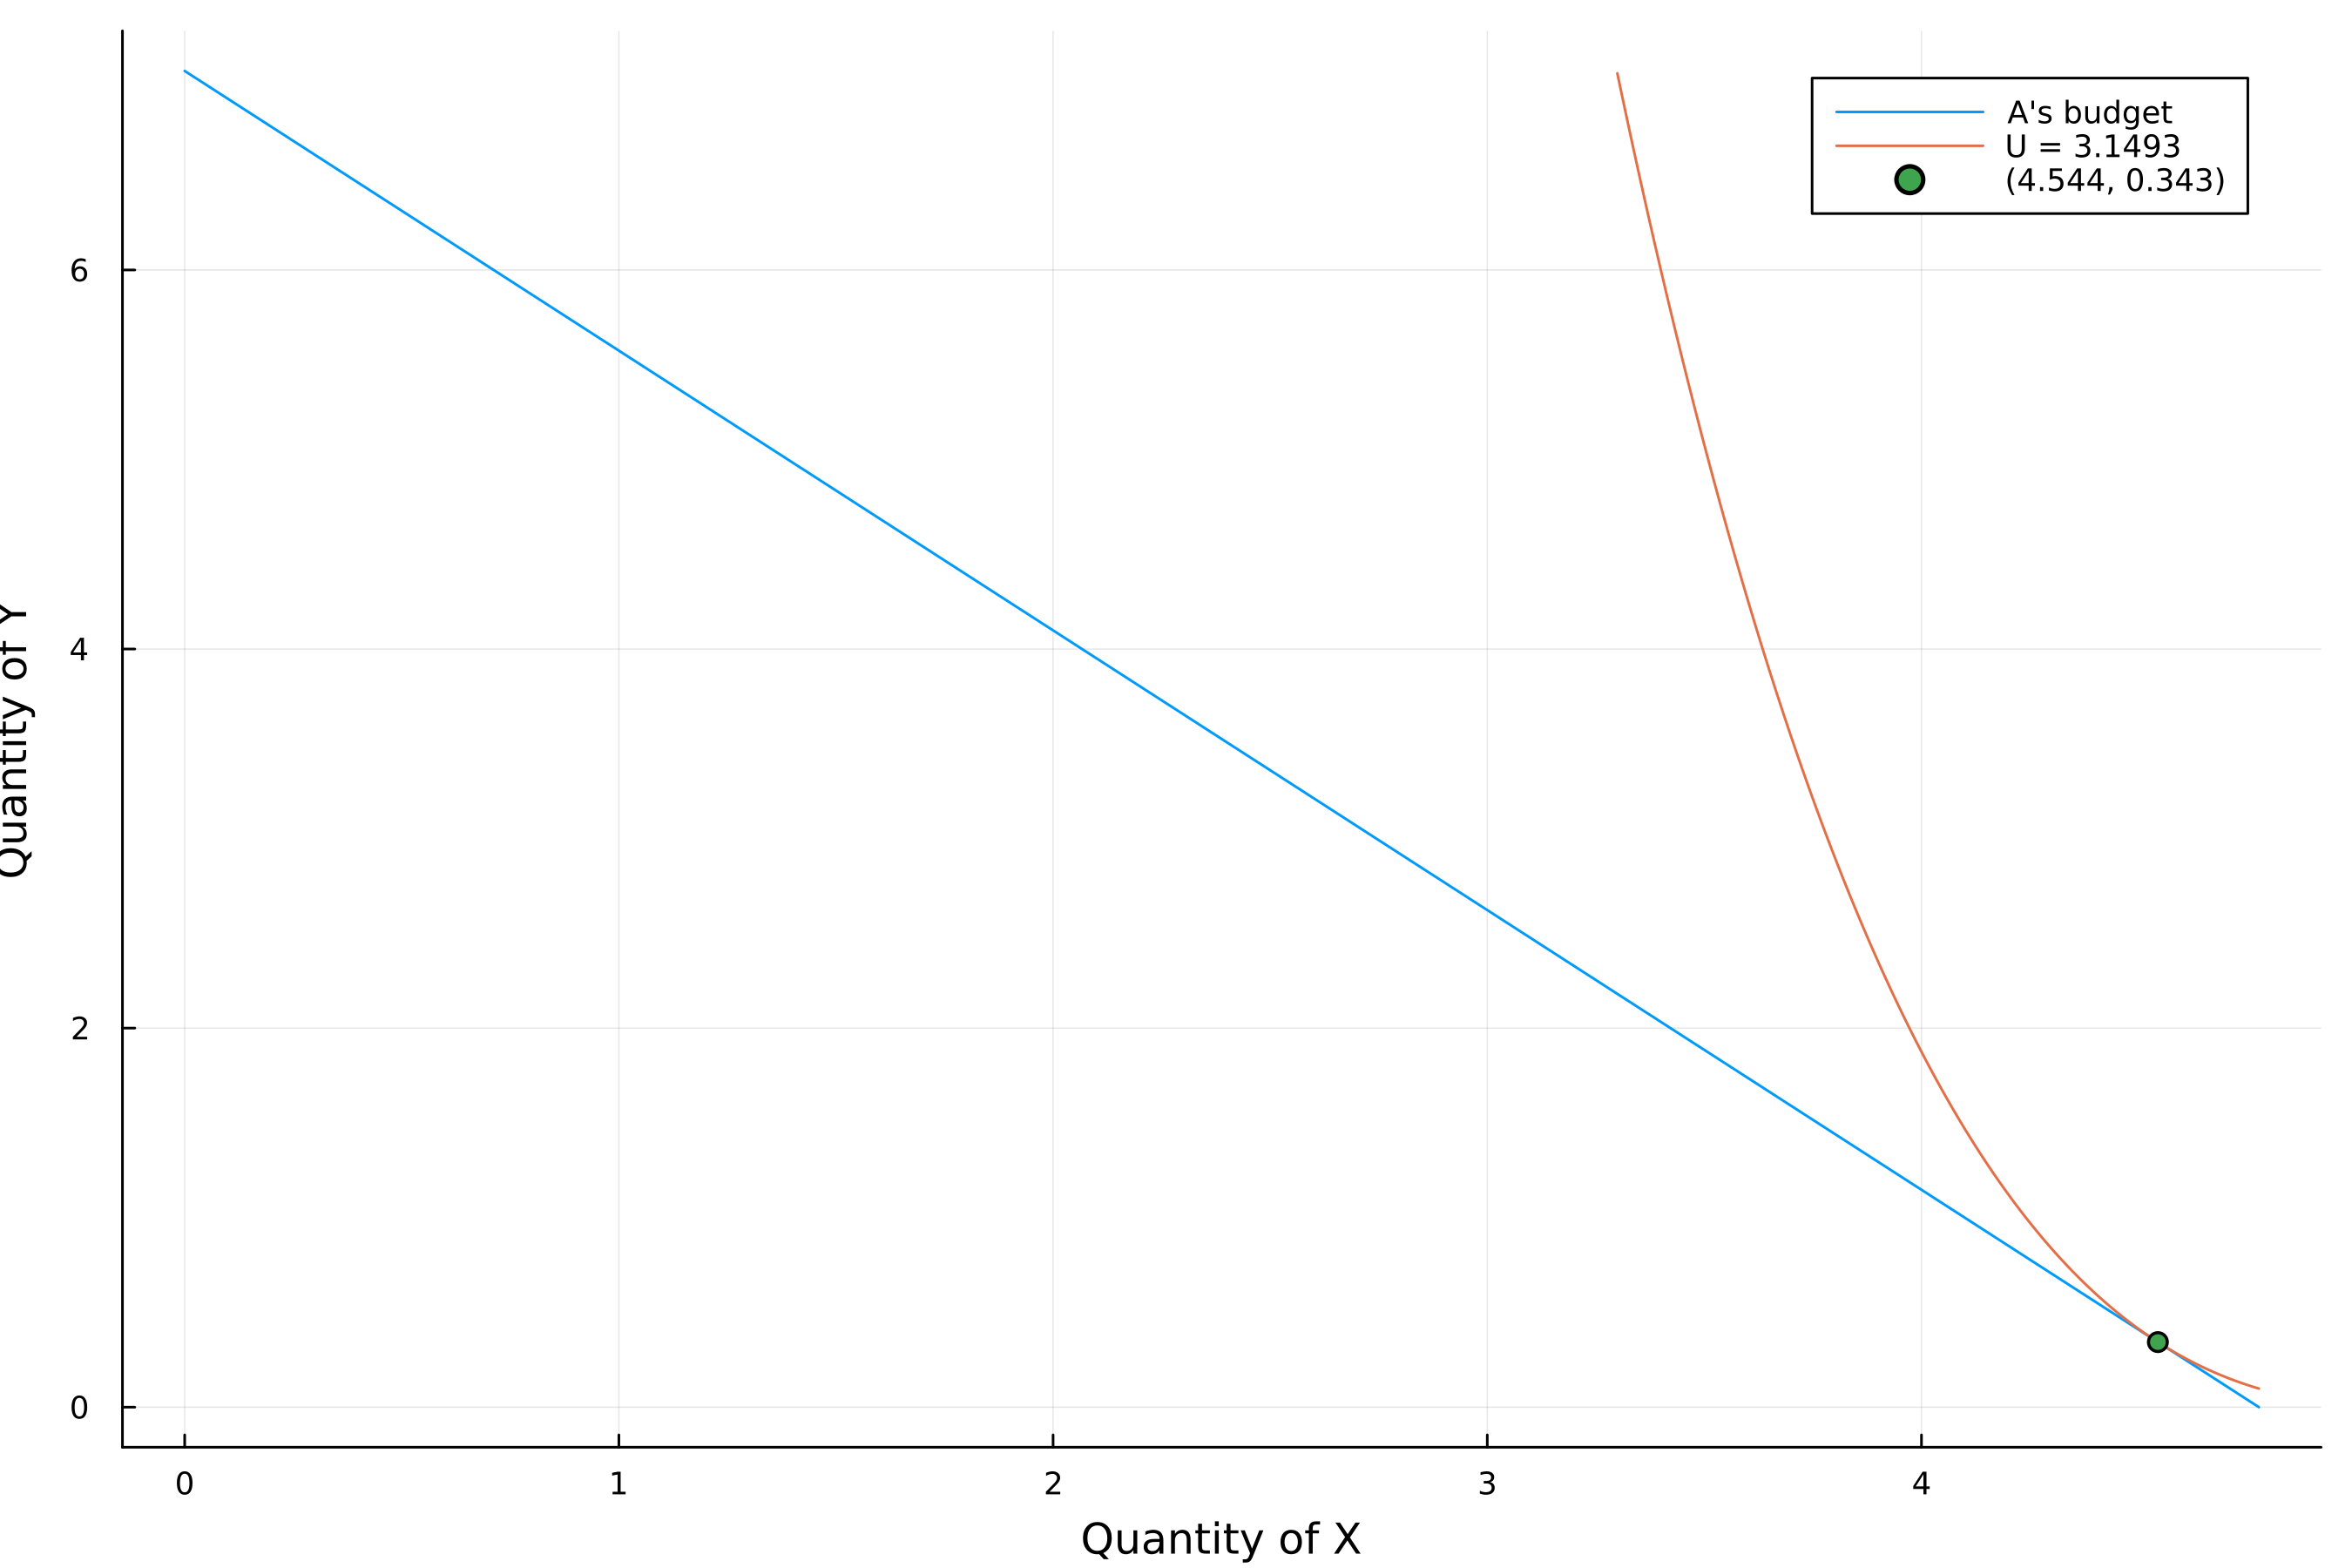

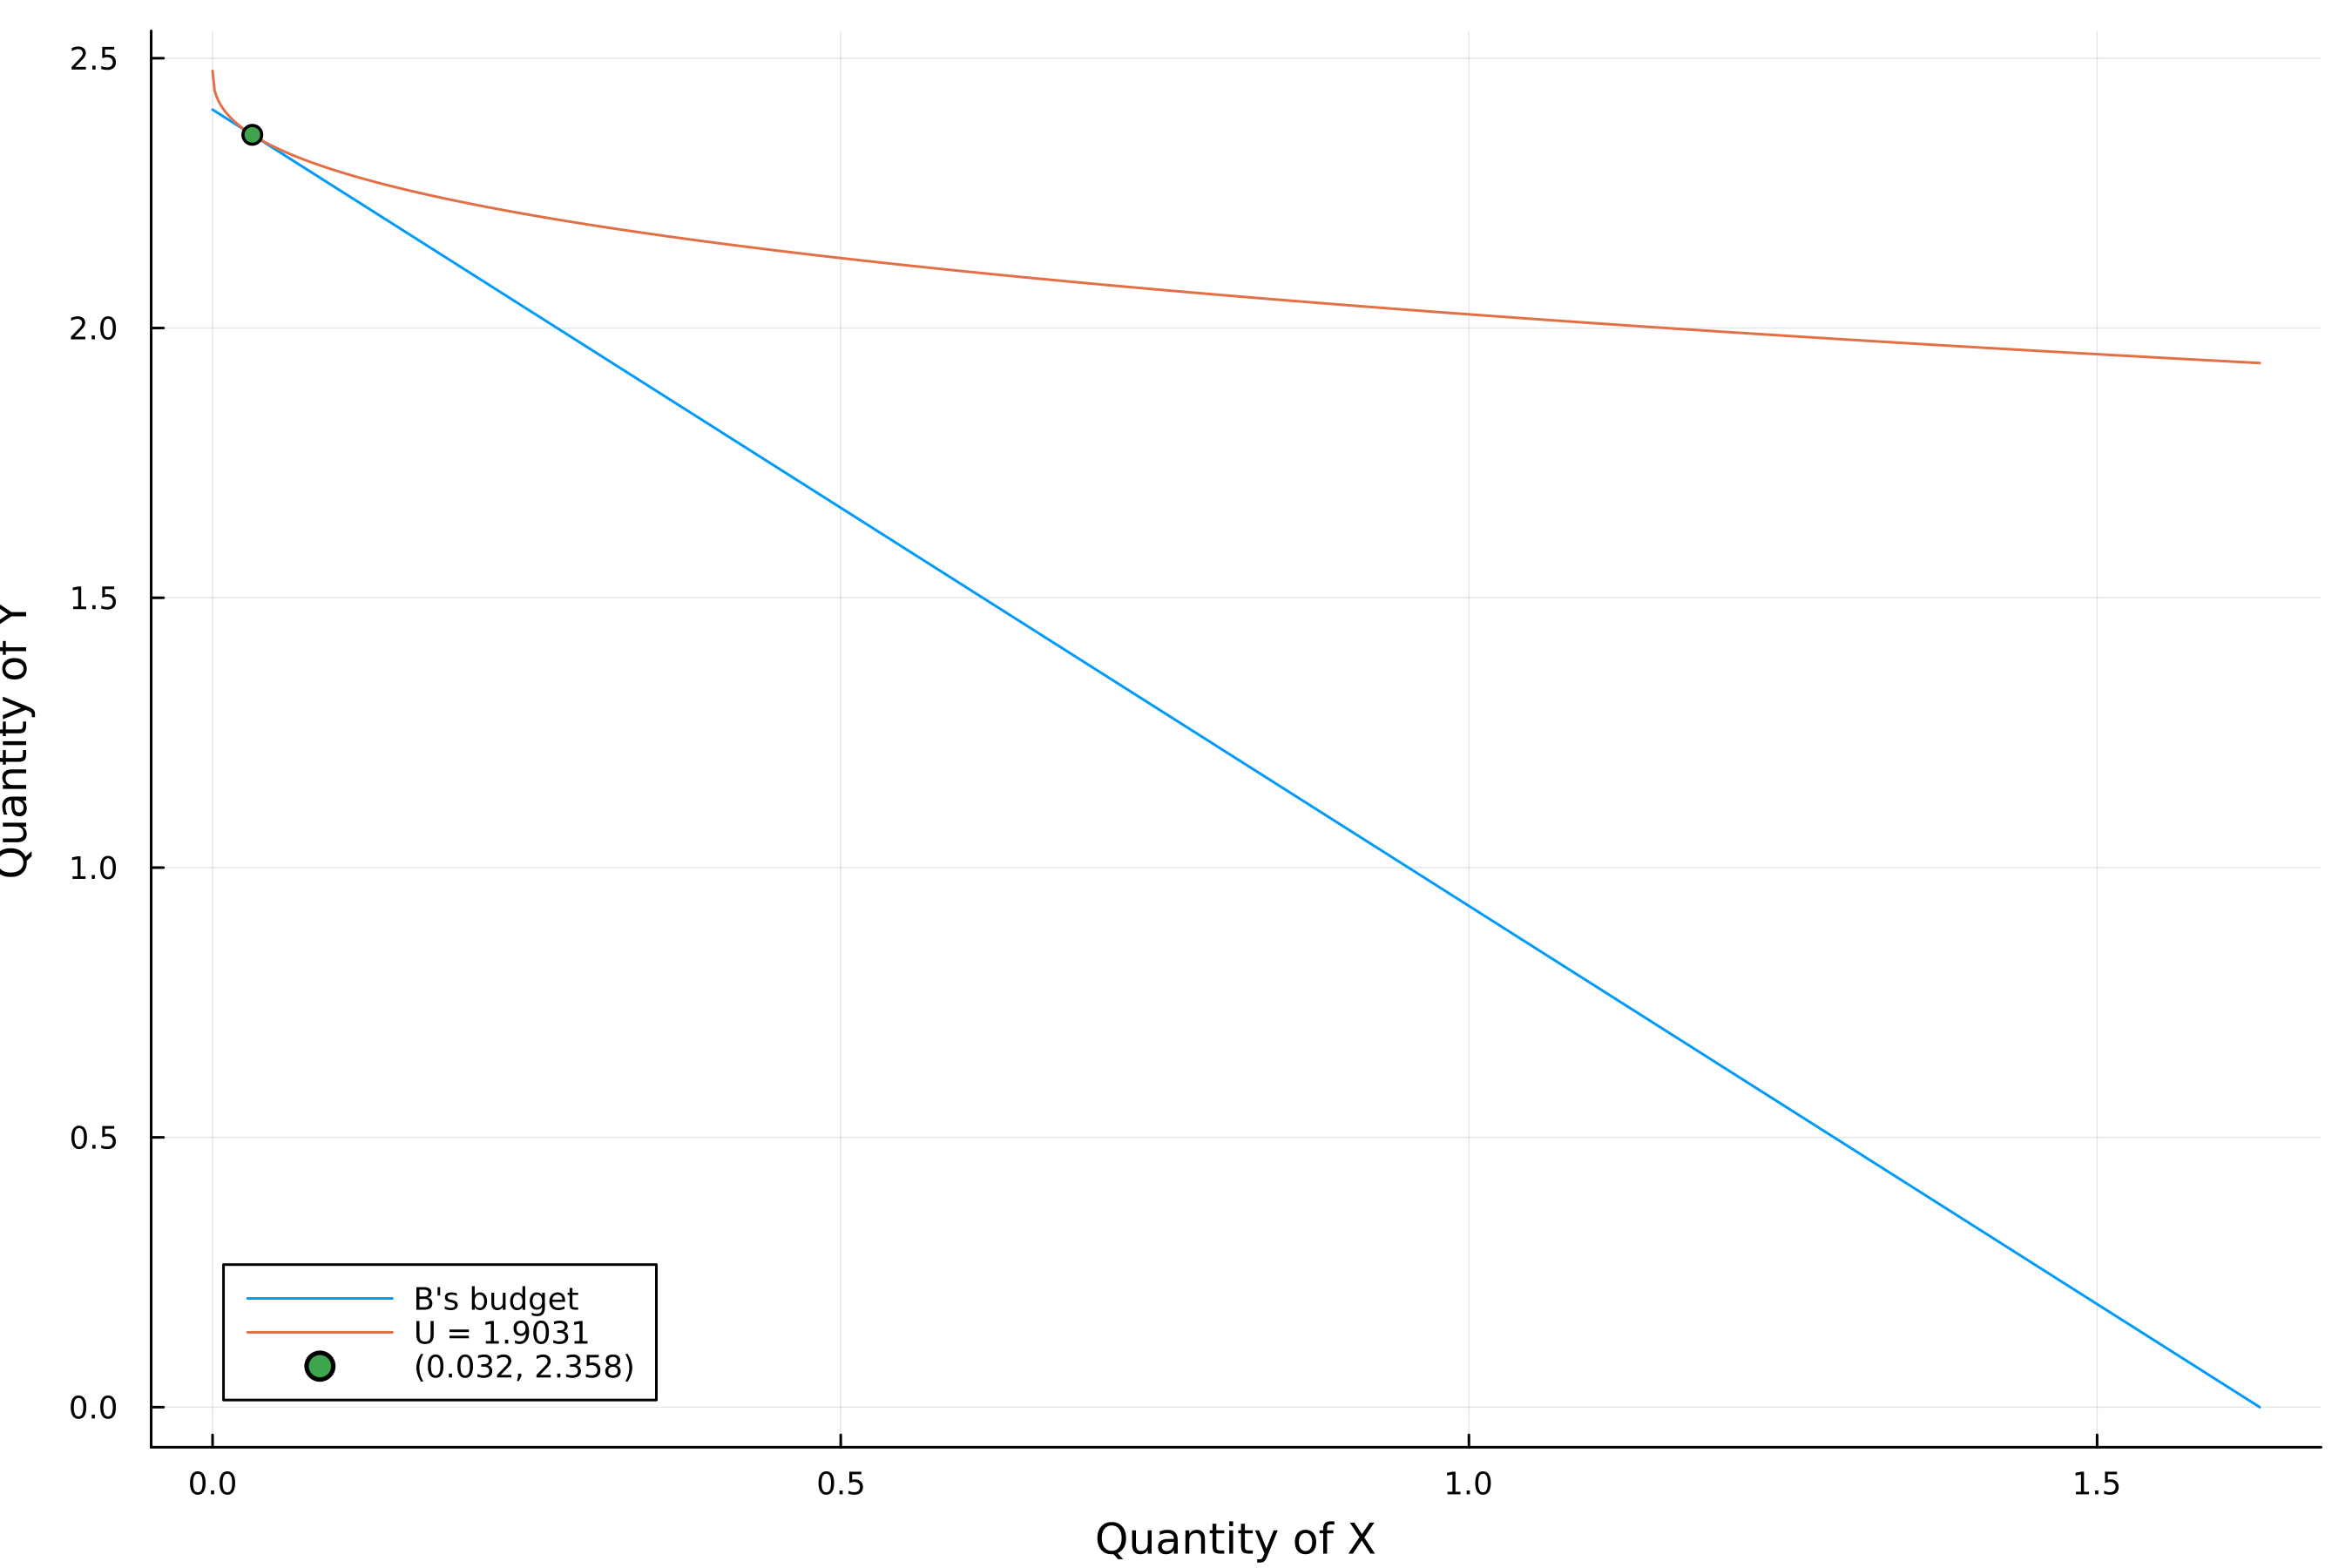

In [9]:
gr()
# begin individual household consumer choice diagrams
pa = plot(inc_a_range, bc_a, labels = "A's budget", xlabel = "Quantity of X", ylabel = "Quantity of Y" )
pa = plot!(inc_a_range[findall(ic_a .< (inc_a/solution_output[var_indx.p]))], ic_a[ic_a .< (inc_a/solution_output[var_indx.p])], labels = "U = "*string(round(value_function_a, digits = 4)))
pa = scatter!( 
    [solution_output[var_indx.x_a]], 
    [solution_output[var_indx.y_a]], 
    labels = string((round(solution_output[var_indx.x_a], digits = 3), round(solution_output[var_indx.y_a], digits=3))))

pb = plot(inc_b_range, bc_b, labels = "B's budget", xlabel = "Quantity of X", ylabel = "Quantity of Y" )
pb = plot!(inc_b_range, ic_builder.(inc_b_range, Ref(value_function_b), Ref(solution_output[var_indx.N]), Ref(parameter_vec), "b"), labels = "U = "*string(round(value_function_b, digits = 4)))
pb = scatter!( 
    [solution_output[var_indx.x_b]], 
    [solution_output[var_indx.y_b]], 
    labels = string((round(solution_output[var_indx.x_b], digits = 3), round(solution_output[var_indx.y_b], digits=3))))

display(pa)
display(pb)

Now we've gotten a nice, visual sense of the sort of "inverse symmetry" between the two households choices from the results of the "Quick example" earlier. The households have very different incomes, and preferences that are asymmetric but in a complementary way. Household A is a fan of good X; Household B has a preference for Good Y.

Now, let's combine these two into one Edgeworth Box.

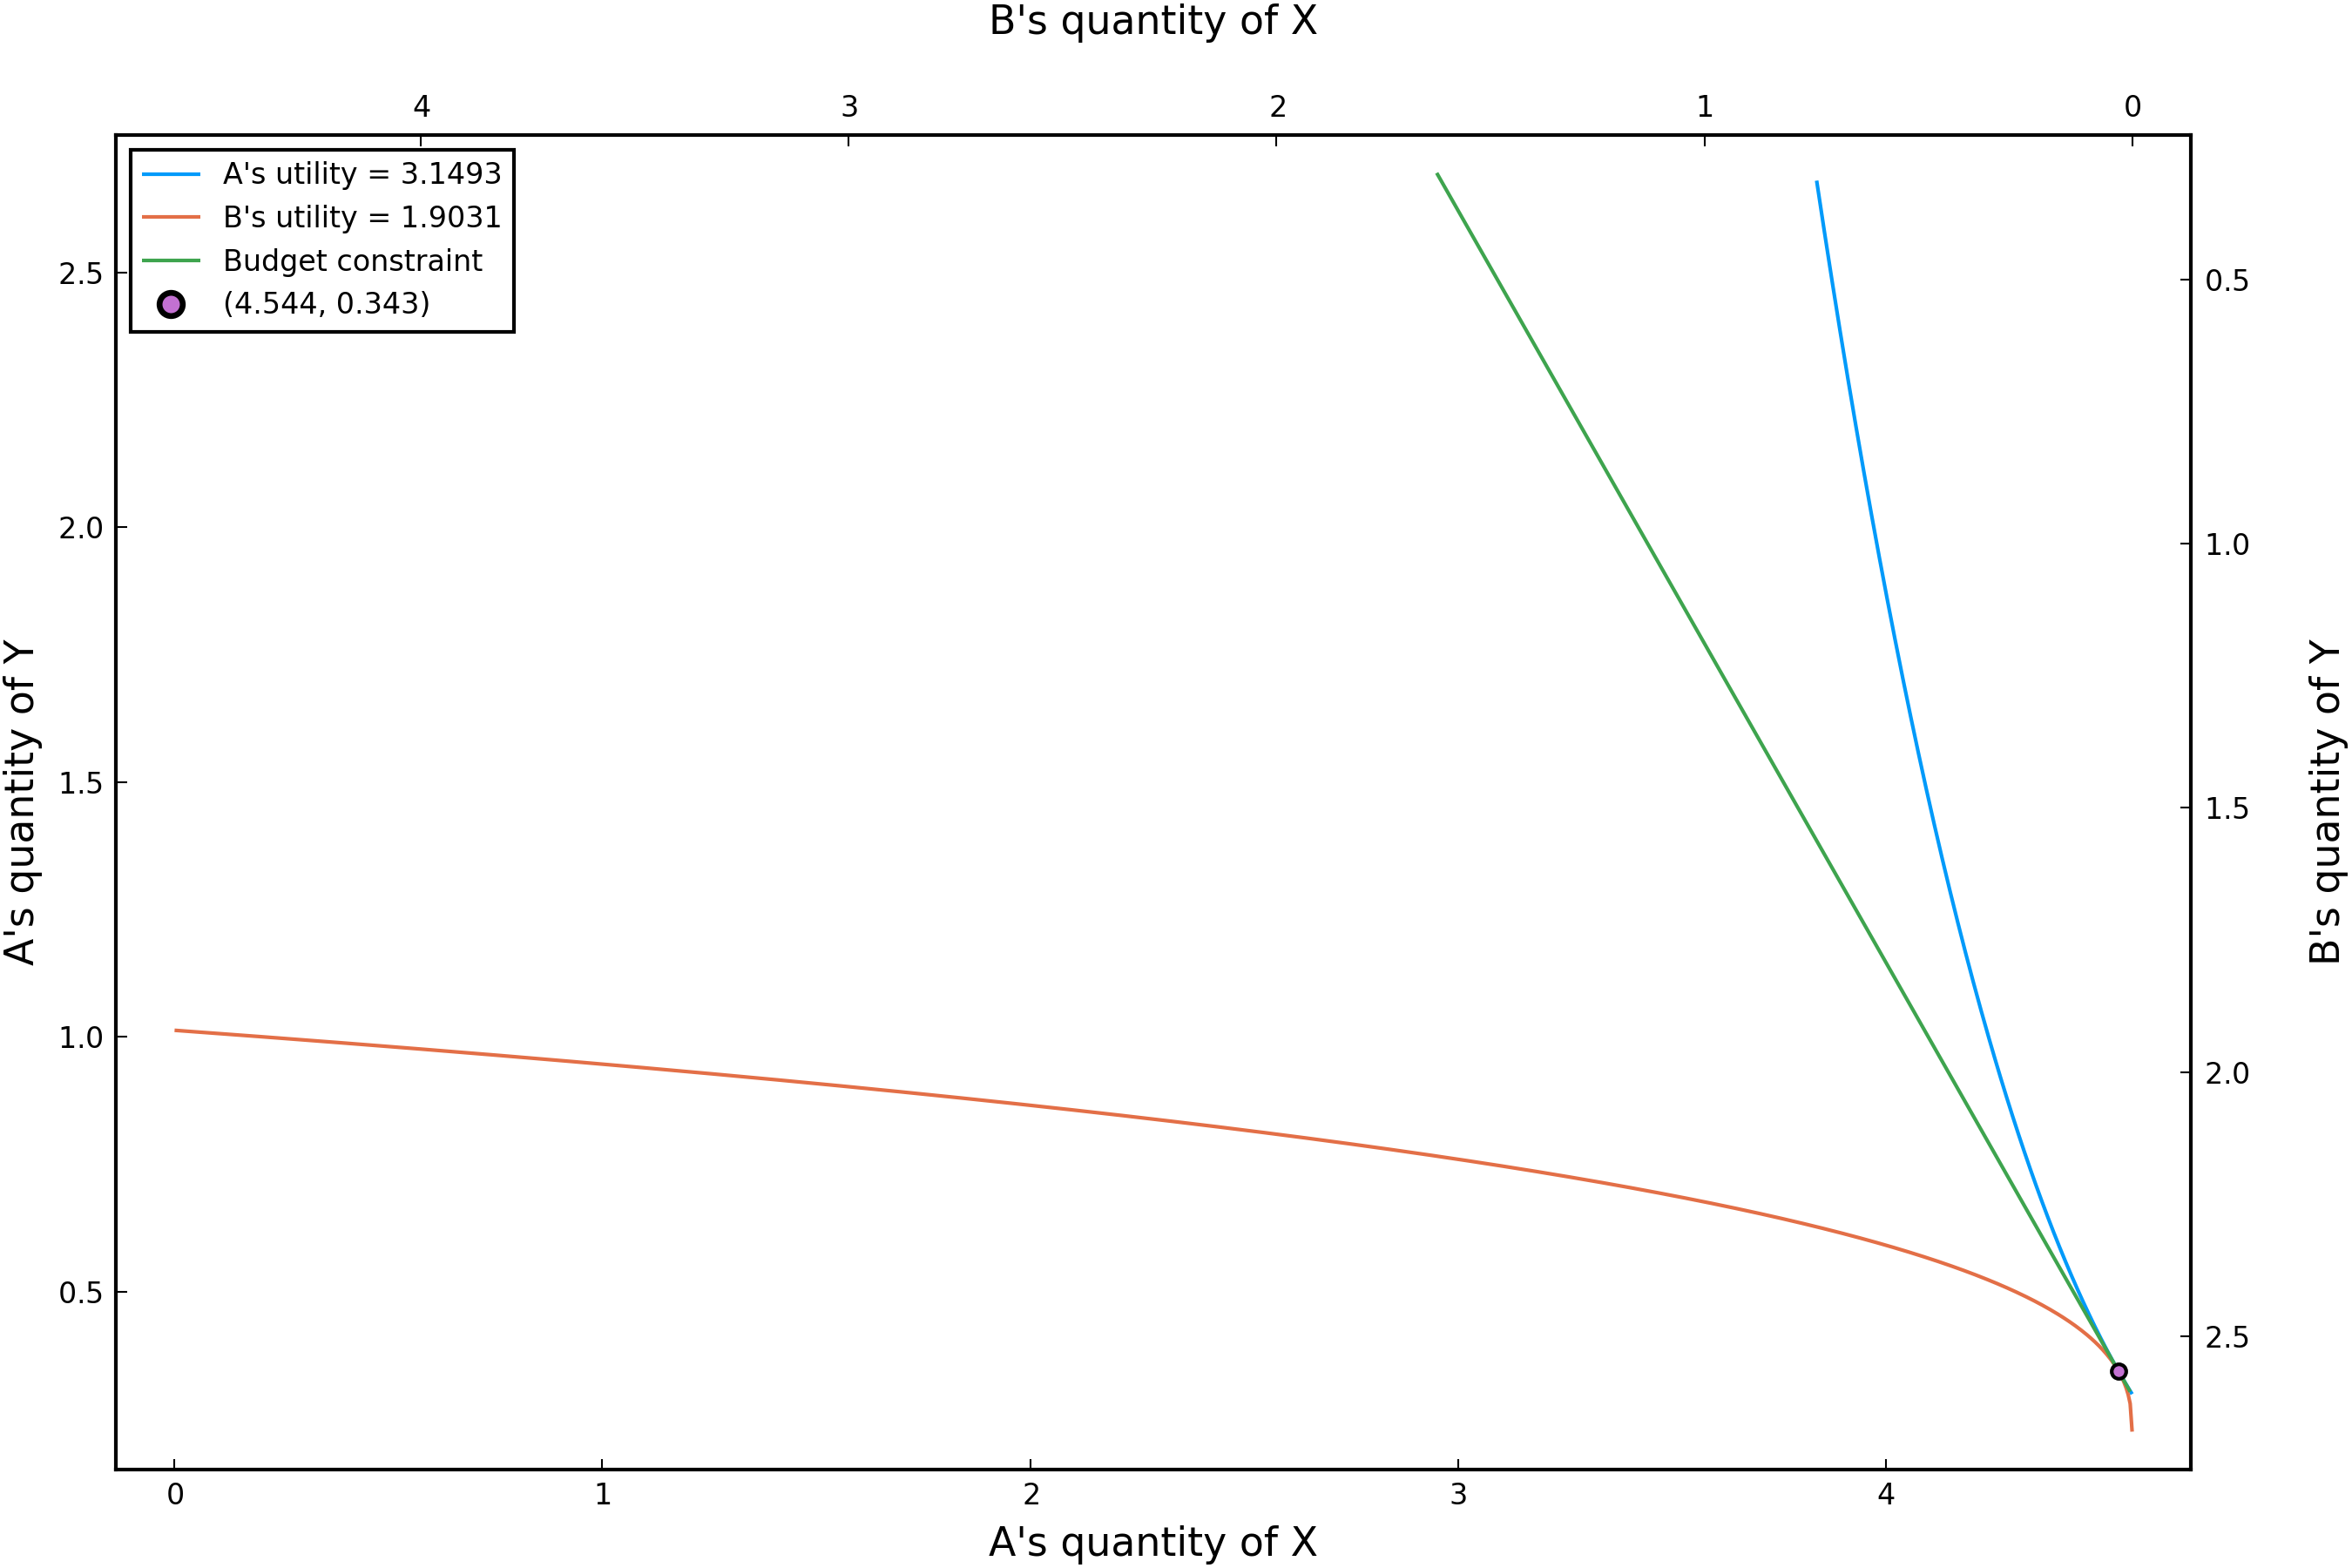

<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [ ]:
pythonplot()
# begin Edgeworth box section
ici_a = ic_builder.(range(0,x_tot,length=1000), Ref(value_function_a), Ref(solution_output[var_indx.N]), Ref(parameter_vec), "a")
ici_b = y_tot .- ic_builder.((x_tot.-range(0, x_tot, 1000)), Ref(value_function_b), Ref(solution_output[var_indx.N]), Ref(parameter_vec), "b")

pt = plot(range(0,x_tot,length=1000)[findall( ici_a .< y_tot )], 
    ici_a[findall( ici_a .< y_tot )], 
    labels = "A's utility = "*string(round(value_function_a, digits=4) ),
    framestyle=:box )
pt = plot!(range(0, x_tot, length=1000), ici_b, labels = "B's utility = "*string(round(value_function_b, digits=4) ) )
pt = plot!(inc_a_range[findfirst(bc_a .< y_tot):findlast(inc_a_range.<x_tot)], 
    bc_a[findfirst(bc_a .< y_tot):findlast(inc_a_range.<x_tot)], 
    labels = "Budget constraint", 
    xlabel = "A's quantity of X", 
    ylabel = "A's quantity of Y",
    legend=:topleft )
pt = scatter!( 
    [solution_output[var_indx.x_a]], 
    [solution_output[var_indx.y_a]], 
    labels = string((round(solution_output[var_indx.x_a], digits = 3), round(solution_output[var_indx.y_a], digits=3)))
    )
pt = plot!(twinx(),
    range(0,x_tot,length=1000), 
    ici_a[findall( ici_a .< y_tot )],
    yflip = true,
    ylabel = "\nB's quantity of Y",
    alpha=0, gridalpha=0, legend=:none, 
    left_margin = 10Plots.mm)
pt = plot!(twiny(),
    range(0,x_tot,length=1000), 
    ici_a[findall( ici_a .< y_tot )],
    xflip=true,
    xlabel = "B's quantity of X\n",
    alpha=0, gridalpha=0, legend=:none, 
    left_margin = 10Plots.mm)

display(pt)

There is an interesting point to stop and note here, because it provides a very useful bridge between human intuition and computational reality. Visually, we can see that the solution looks like it's "wedged" in the corner; the households' preference parameters are so strongly skewed in the direction of each good that we get close to a *literal* "corner solution." When tweaking some of the fixed parameters feeding the model, you can imagine how -- being this close to the corners -- the solutions start to become numerically unstable. At first, and without seeing the solution graphically, it seems like a limitation of computers trying to numerically solve a nonlinear system. However, visualizing helps us see how even slight changes to the parameter space can make the optimal price $p$ "swing" wildly, and when we get this close to literal corner solutions, it's clear why finding that solution computationally difficult.

Below, you will see the above Edgeworth Box, only with more indifference contours added to help visualize and better-understand the utility space of the model. Cyan (the steeper curves) is Household A's utility, while magenta (the flatter curves) are Household B's utility. Note the utility values attached to each indifference curve.

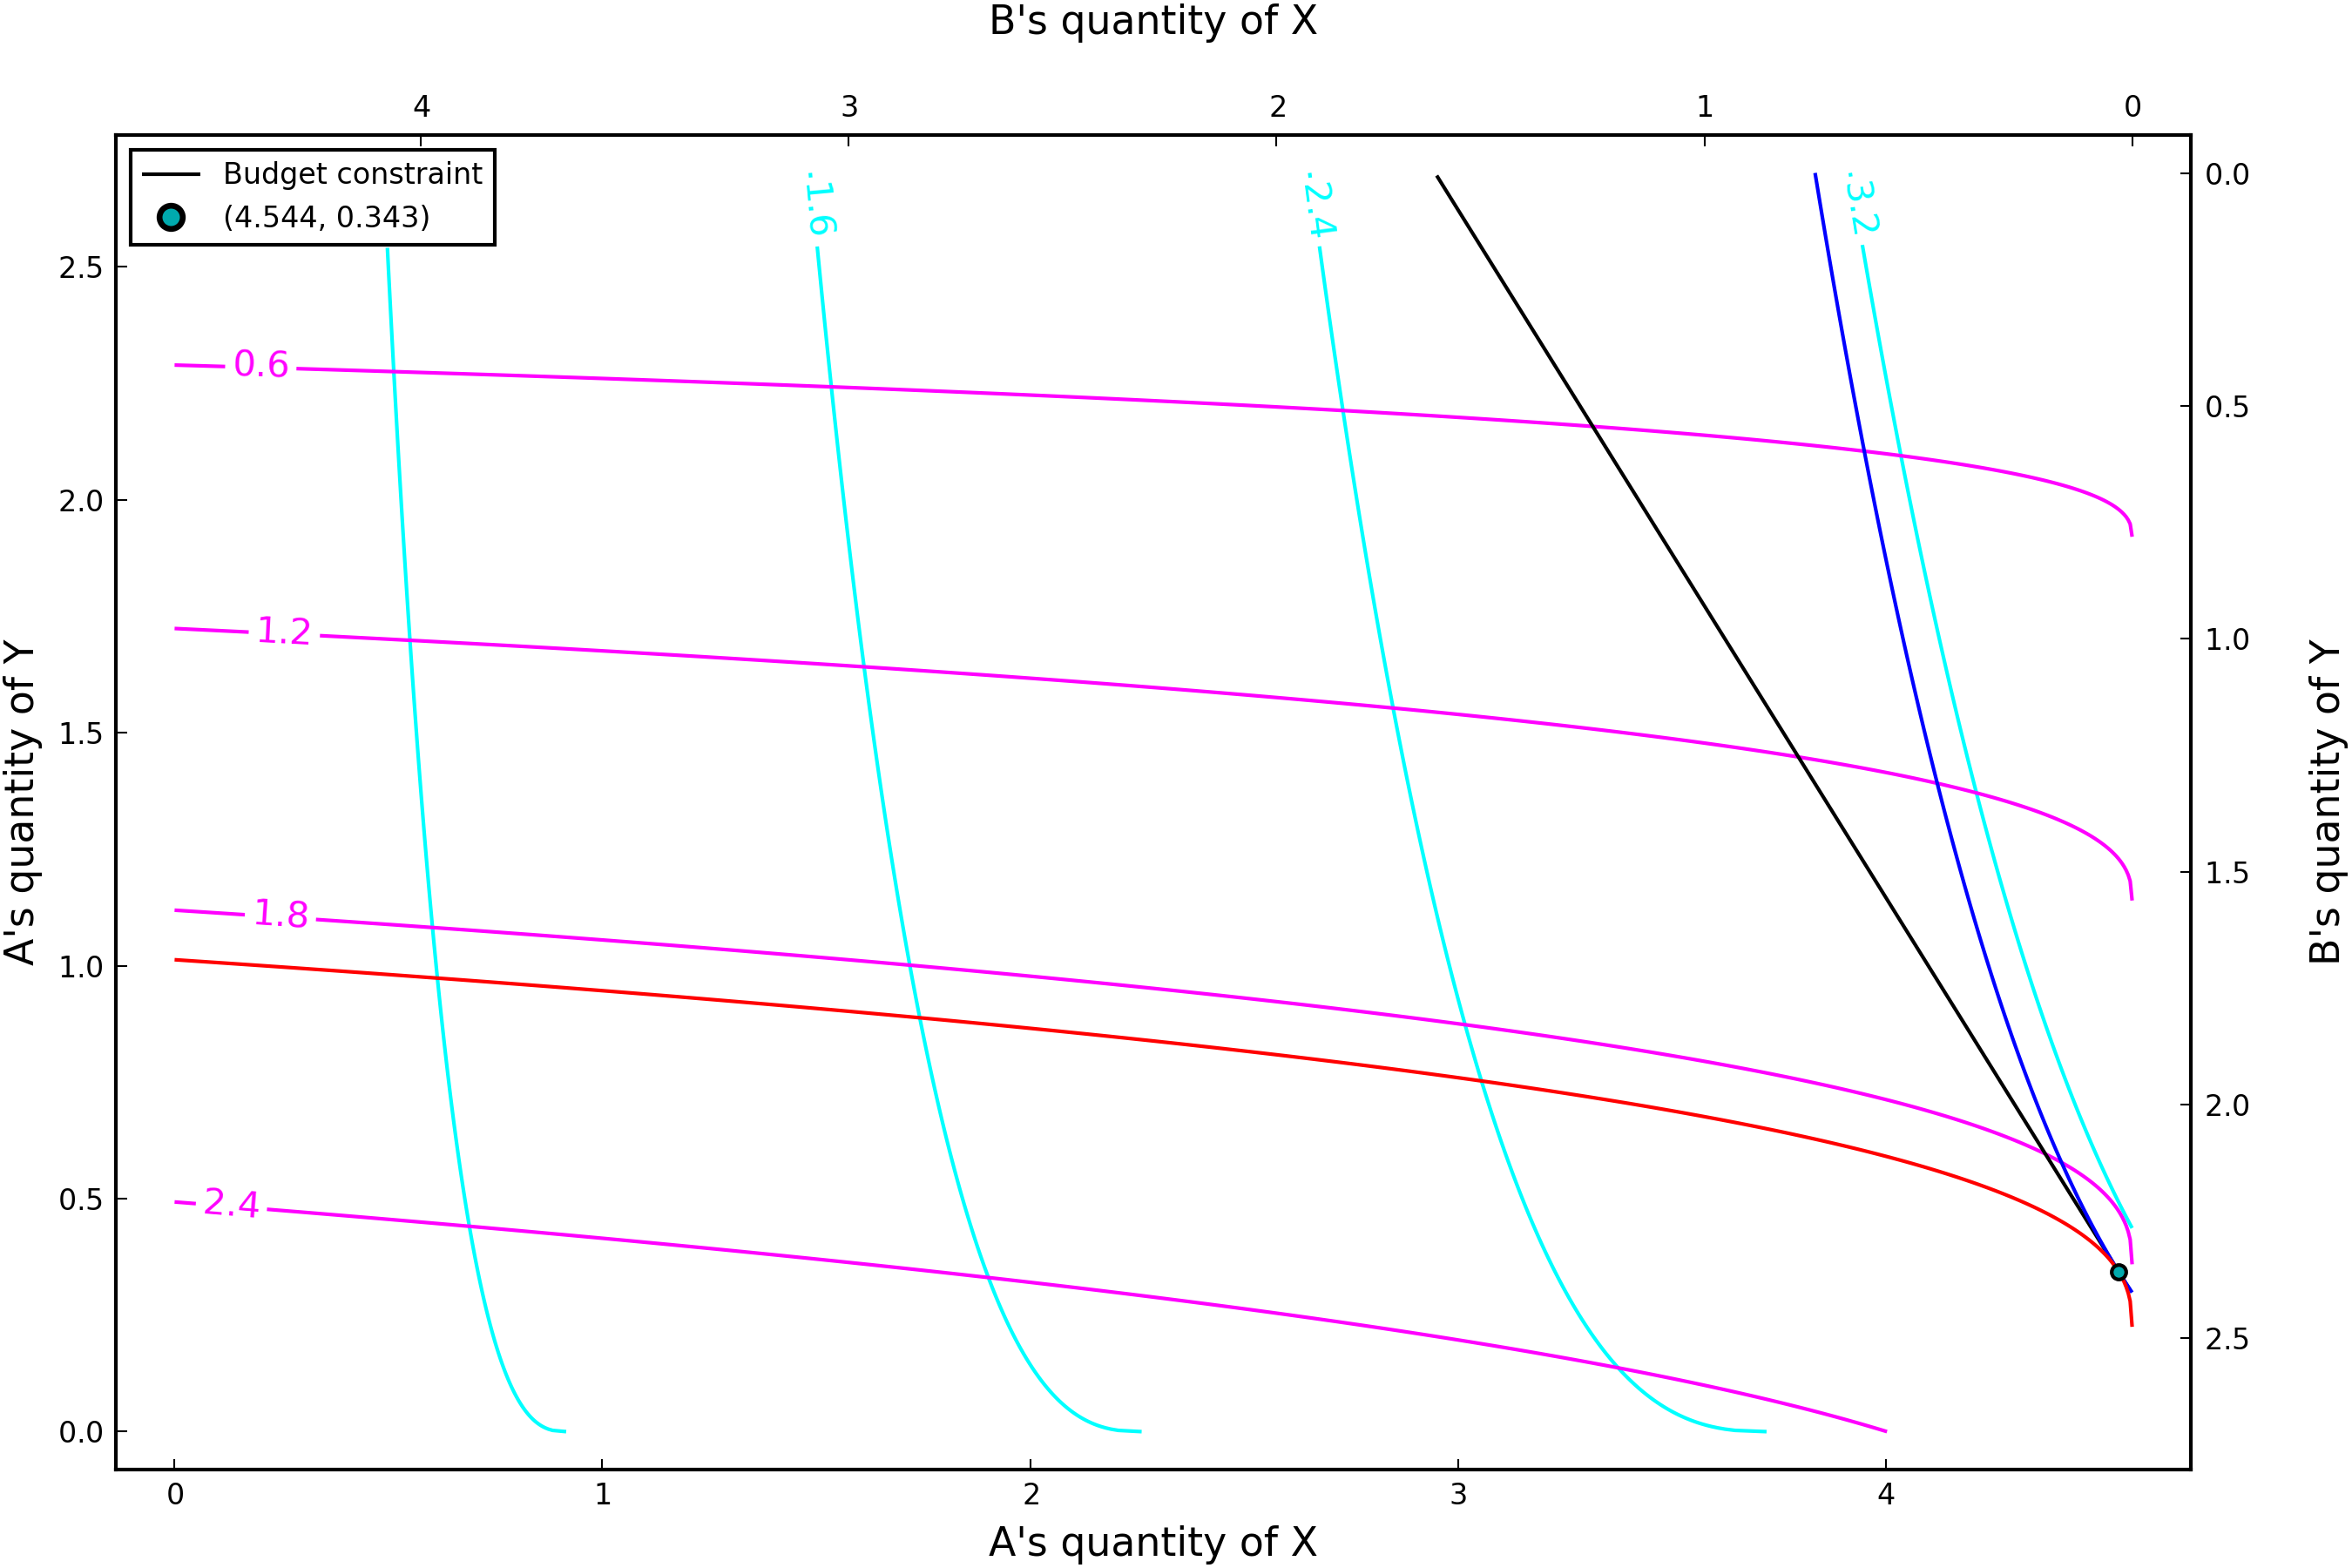

<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [13]:

# begin Edgeworth box contour plotting
x_ua = range(0, x_tot, length=1000)
y_ua = range(0, y_tot, length = 1000)
z_ua = @. u_wrapper(x_ua', y_ua, x_tot, y_tot, "a")
z_ub = @. u_wrapper(x_ua', y_ua, x_tot, y_tot, "b")

pythonplot()
ca = contour(x_ua, 
    y_ua, 
    z_ua, 
    xlabel = "A's quantity of X", 
    ylabel = "A's quantity of Y", 
    colorbar=false, 
    levels=4, 
    color = [:cyan],
    legend=:topleft,
    clabels=true,
    framestyle=:box)
ca = contour!(x_ua, y_ua, z_ub, levels=4, clabels=true, color = [:magenta])
ca = plot!(inc_a_range[findfirst(bc_a .< y_tot):findlast(inc_a_range.<x_tot)], bc_a[findfirst(bc_a .< y_tot):findlast(inc_a_range.<x_tot)], linecolor =:black, labels="Budget constraint" )
ca = contour!(x_ua, y_ua, z_ua, levels = [value_function_a], lc=[:blue])
ca = contour!(x_ua, y_ua, z_ub, levels = [value_function_b], lc=[:red])
ca = scatter!( 
    [solution_output[var_indx.x_a]], 
    [solution_output[var_indx.y_a]], 
    labels = string((round(solution_output[var_indx.x_a], digits = 3), round(solution_output[var_indx.y_a], digits=3))))
ca = plot!(twinx(), 
    x_ua, y_ua, 
    yflip = true, alpha=0, legend=:none, 
    ylabel = "\nB's quantity of Y" )
ca = plot!( twiny(),
    x_ua, y_ua, 
    xflip = true, alpha=0, legend=:none, 
    xlabel = "B's quantity of X\n" )

display(ca)

## Parting observations; thoughts

There are other facets of this extension worth exploring. However, I hope this "under the hood" peek has given you a sense of how the extended 2-household works. You are free to take this model and perhaps you can use it to run a simulation showing the [contract curve](https://en.wikipedia.org/wiki/Contract_curve) that results from this model. A related, interesting next direction would be plotting the [production-possibility frontier](https://en.wikipedia.org/wiki/Production%E2%80%93possibility_frontier). (Please let me know if you do -- I would love to see the code!)

We can see that our worker-- Household A-- ends up with the lion's share of the income in this model. Household B gets most of Good Y, but overall, Household A has more income. It would be particularly interesting to add a redistributive government to the model, although [some schools of thought](https://en.wikipedia.org/wiki/Means_of_production#Marxism_and_Marxist_theory_of_class) would undoubtedly take issue with redistributing worker income to a nonworking *rentier class*. However, there is no reason why the two households couldn't both be workers-- but differentiated by the type of work they do, and income they receive from it. College vs. non-college educated, for example. We could look at different kinds of taxes-- taxes on wages for one household, or capital taxation. In the end we would find that [lump sum taxation is first-best efficient](https://en.wikipedia.org/wiki/Fundamental_theorems_of_welfare_economics#Proof_of_the_second_fundamental_theorem), only we could evaluate the relative efficiency numerically thanks to this model. Generally, having a second household makes the model much more flexible for such policy analyses, so keep your eyes open for another writeup.